# **Phase 1: Environment Setup & Data Preparation**

In [2]:
!pip install shapely
!pip install segmentation-models-pytorch
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01


In [3]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

Found 1500 JSON files. Starting conversion...


  0%|          | 0/1500 [00:00<?, ?it/s]

Masks saved to /kaggle/working/train_masks


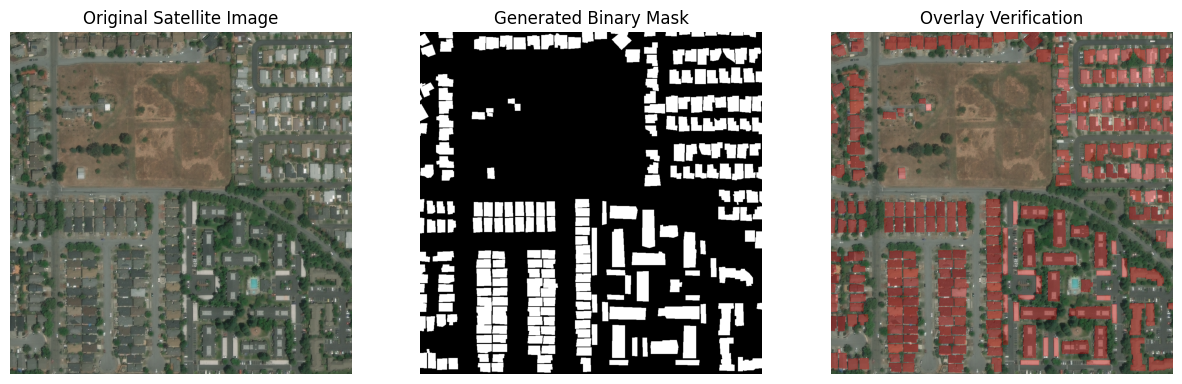

In [4]:
import json
import numpy as np
import cv2
from shapely import wkt
import os
from glob import glob
from tqdm.notebook import tqdm # Optimized for Jupyter/Kaggle notebooks
import matplotlib.pyplot as plt

def create_mask_from_json(json_path, output_path, image_size=(1024, 1024)):
    """Reads an xView2 JSON label file and generates a binary PNG mask."""
    # Create a blank black mask (0 = background)
    mask = np.zeros(image_size, dtype=np.uint8)

    with open(json_path, 'r') as f:
        label_data = json.load(f)

    # The polygons are stored under 'features' -> 'xy'
    if 'features' in label_data and 'xy' in label_data['features']:
        for feature in label_data['features']['xy']:
            wkt_polygon = feature['wkt']
            poly = wkt.loads(wkt_polygon)
            
            # Extract the exterior coordinates of the polygon
            coords = np.array(poly.exterior.coords, dtype=np.int32)
            
            # Fill the polygon on our mask canvas with 1 (building footprint)
            cv2.fillPoly(mask, [coords], color=1)

    # Save the mask as a PNG file
    cv2.imwrite(output_path, mask)

def batch_process_masks(json_dir, output_dir, limit=None):
    """Processes JSON files. Added a 'limit' parameter to test on a small batch first."""
    os.makedirs(output_dir, exist_ok=True)
    json_files = glob(os.path.join(json_dir, "*.json"))
    
    if limit:
        json_files = json_files[:limit]
        
    print(f"Found {len(json_files)} JSON files. Starting conversion...")
    
    for json_path in tqdm(json_files):
        # Create a matching filename but with a .png extension
        filename = os.path.basename(json_path).replace('.json', '.png')
        output_path = os.path.join(output_dir, filename)
        
        create_mask_from_json(json_path, output_path, image_size=(1024, 1024))
    print(f"Masks saved to {output_dir}")

def verify_overlay(image_path, mask_path):
    """Visualizes the original image, the generated mask, and the overlay."""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # Create an overlay by highlighting the mask area in red
    overlay = img.copy()
    overlay[mask == 1] = [255, 0, 0] 
    
    # Blend the image and the overlay
    blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title("Original Satellite Image")
    axes[0].axis("off")
    
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Generated Binary Mask")
    axes[1].axis("off")
    
    axes[2].imshow(blended)
    axes[2].set_title("Overlay Verification")
    axes[2].axis("off")
    
    plt.show()

# ==========================================
# EXECUTION BLOCK (Using your exact structure)
# ==========================================

# Standard Kaggle mount path based on your screenshot
JSON_DIR = '/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train/labels'
IMAGE_DIR = '/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train/images'
OUTPUT_DIR = '/kaggle/working/train_masks'


batch_process_masks(JSON_DIR, OUTPUT_DIR, limit=1500)

sample_json = glob(os.path.join(JSON_DIR, "*.json"))[0]
sample_filename_base = os.path.basename(sample_json).replace('.json', '')

sample_img_path = os.path.join(IMAGE_DIR, sample_filename_base + '.png')
sample_mask_path = os.path.join(OUTPUT_DIR, sample_filename_base + '.png')

# Plot the result
verify_overlay(sample_img_path, sample_mask_path)

# **Phase 2: Data Pipeline & Augmentation**

In [5]:
# Updated Augmentation Pipeline
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGE_SIZE = 256

train_transform = A.Compose([
    # REMOVED A.Resize. Replaced with RandomCrop to preserve pixel resolution!
    A.RandomCrop(width=IMAGE_SIZE, height=IMAGE_SIZE), 
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    # CenterCrop for validation ensures we evaluate on the same scale
    A.CenterCrop(width=IMAGE_SIZE, height=IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [6]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

print("Setting up the DataLoaders...")

# 1. Get the list of files we just successfully generated masks for
# Since we named the masks exactly the same as the images, we can just look at OUTPUT_DIR
available_files = os.listdir(OUTPUT_DIR)

# 2. Split the files: 80% for training, 20% for validation (Unit II Concept)
train_files, val_files = train_test_split(available_files, test_size=0.2, random_state=42)
print(f"Dataset split: {len(train_files)} Training images | {len(val_files)} Validation images")

# 3. Update our Dataset class to accept a specific list of files
class DisasterDamageDataset(Dataset):
    def __init__(self, image_dir, mask_dir, file_list, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.file_list = file_list  # We pass our split list here
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, index):
        filename = self.file_list[index]
        img_path = os.path.join(self.image_dir, filename)
        mask_path = os.path.join(self.mask_dir, filename)

        # Read and convert
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Binarize mask
        mask = (mask > 0).astype(np.float32)

        if self.transform is not None:
            augmentations = self.transform(image=image, mask=mask)
            image = augmentations["image"]
            mask = augmentations["mask"]

        # Add channel dimension
        mask = torch.unsqueeze(mask, 0)
        return image, mask

# 4. Instantiate the Datasets
# We use IMAGE_DIR (from our auto-detect block) and OUTPUT_DIR (where our masks live)
train_dataset = DisasterDamageDataset(IMAGE_DIR, OUTPUT_DIR, train_files, transform=train_transform)
val_dataset = DisasterDamageDataset(IMAGE_DIR, OUTPUT_DIR, val_files, transform=val_transform)

# 5. Create the Loaders
BATCH_SIZE = 8 # A safe batch size for Kaggle GPUs when testing
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("✅ train_loader and val_loader are successfully defined and ready!")

Setting up the DataLoaders...
Dataset split: 1200 Training images | 300 Validation images
✅ train_loader and val_loader are successfully defined and ready!


# **Phase 3: Model Architecture & Initialization**

In [7]:
import torch
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim

# 1. Set the device (Kaggle T4 or P100 GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Instantiate the U-Net model with a pre-trained ResNet34 backbone
# We use in_channels=3 for RGB images, classes=1 for binary output (building mask)
model = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights="imagenet",     # Use pre-trained weights for faster convergence
    in_channels=3,                  
    classes=1,                      
).to(device)

# 3. Define the Loss Function and Optimizer (Unit II concepts)
# SMP provides a combined Dice + BCE loss which is perfect for this
loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)

# Adam optimizer with a standard learning rate
optimizer = optim.Adam(model.parameters(), lr=0.001)


print("Model, Loss, and Optimizer initialized successfully!")

Using device: cuda


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model, Loss, and Optimizer initialized successfully!


In [8]:
# Create a dummy image tensor that matches our data loader output 
# Shape: (Batch Size, Channels, Height, Width) -> (1, 3, 256, 256)
dummy_input = torch.randn(1, 3, 256, 256).to(device)

# Pass it through the model
with torch.no_grad():
    dummy_output = model(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}") 
# Expected Output shape: [1, 1, 256, 256] (A single-channel mask)

Input shape: torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])


# **Phase 4: Model Training & Validation**

In [9]:
from tqdm.notebook import tqdm
import numpy as np
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ==========================================
# 1. BULLETPROOF INITIALIZATION
# ==========================================

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

EPOCHS = 30 
best_valid_loss = float("inf")

train_loss_history = []
valid_loss_history = []

print("Starting Training Loop with LR Scheduler...")

# ==========================================
# 2. TRAINING LOOP
# ==========================================
for epoch in range(EPOCHS):
    # Grab the current learning rate to display it since we can't use verbose=True
    current_lr = optimizer.param_groups[0]['lr']
    print(f"\nEpoch: {epoch+1} / {EPOCHS} | Current LR: {current_lr}")
    
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    
    for images, masks in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, masks)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)
    
    # --- VALIDATION PHASE ---
    model.eval()
    valid_loss = 0.0
    
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            masks = masks.to(device)
            
            logits = model(images)
            loss = loss_fn(logits, masks)
            
            valid_loss += loss.item()
            
    avg_valid_loss = valid_loss / len(val_loader)
    valid_loss_history.append(avg_valid_loss)
    
    print(f"Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_valid_loss:.4f}")
    
    # --- LEARNING RATE SCHEDULER STEP ---
    scheduler.step(avg_valid_loss) 
    
    # --- SAVE THE BEST MODEL ---
    if avg_valid_loss < best_valid_loss:
        print(f"Validation loss improved from {best_valid_loss:.4f} to {avg_valid_loss:.4f}. Saving model...")
        torch.save(model.state_dict(), '/kaggle/working/best_unet_model.pth')
        best_valid_loss = avg_valid_loss

print("\nTraining Complete!")

Starting Training Loop with LR Scheduler...

Epoch: 1 / 30 | Current LR: 0.001


Training:   0%|          | 0/150 [00:00<?, ?it/s]

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train Loss: 0.6664 | Validation Loss: 0.7929
Validation loss improved from inf to 0.7929. Saving model...

Epoch: 2 / 30 | Current LR: 0.001


Training:   0%|          | 0/150 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train Loss: 0.3766 | Validation Loss: 0.3532

Epoch: 30 / 30 | Current LR: 0.00025


Training:   0%|          | 0/150 [00:00<?, ?it/s]

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train Loss: 0.3783 | Validation Loss: 0.3710

Training Complete!


# **Phase 5: Inference & Result Visualization**

Loading the best model weights...
Generating predictions...
Saving 8 comparison plots as PNGs...


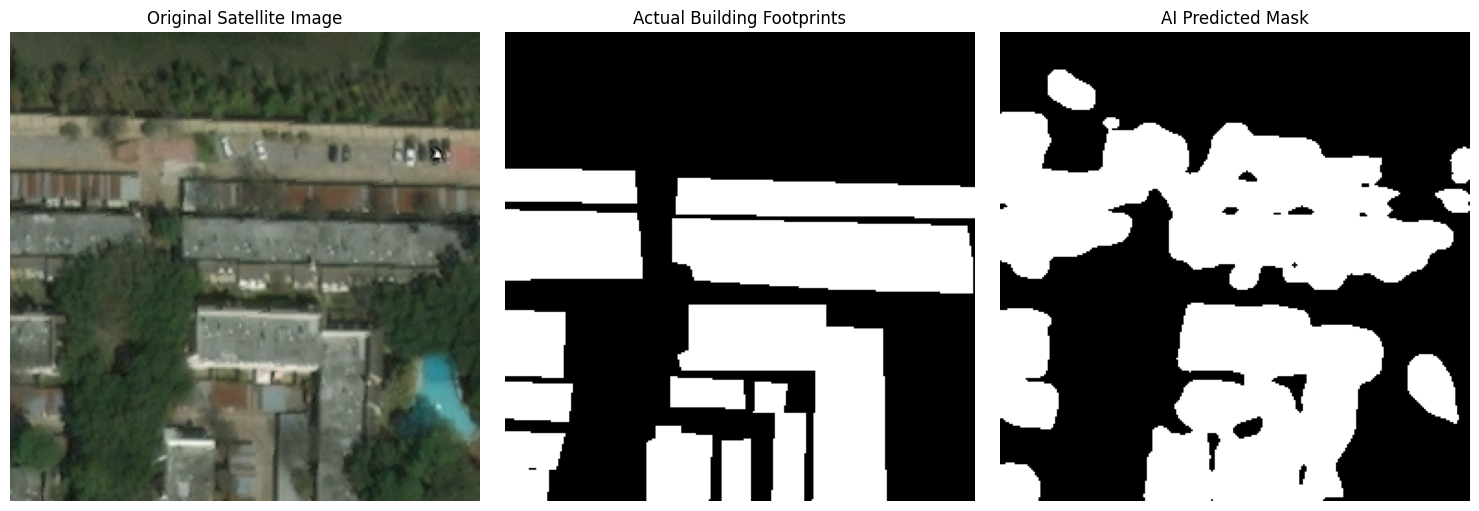

<Figure size 640x480 with 0 Axes>

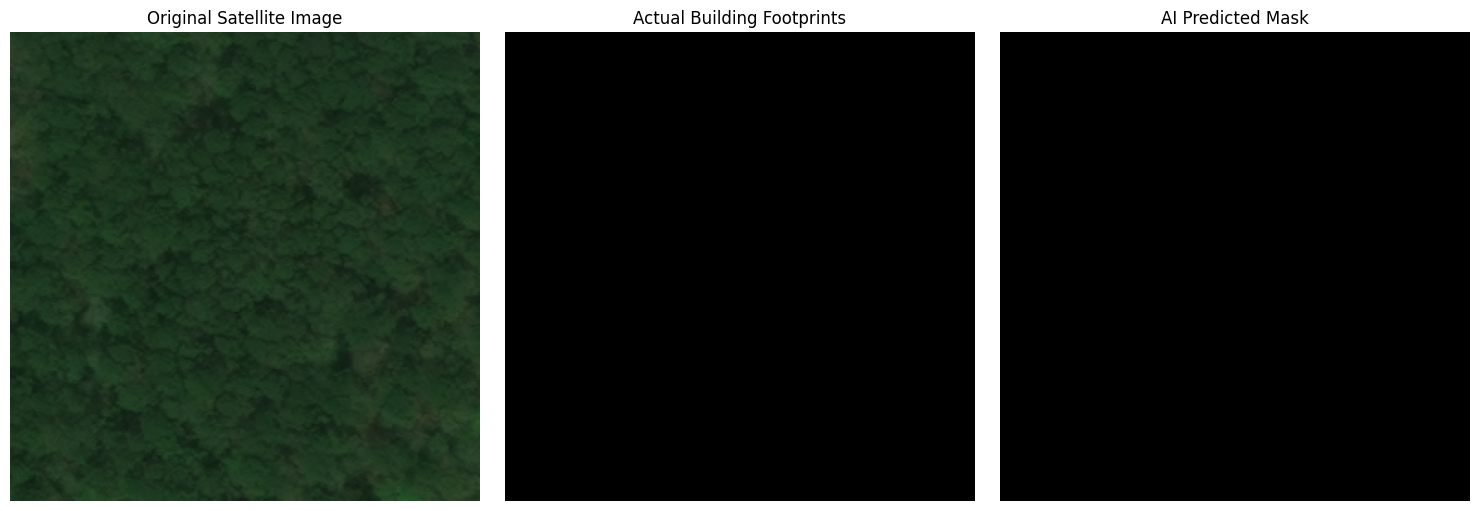

<Figure size 640x480 with 0 Axes>

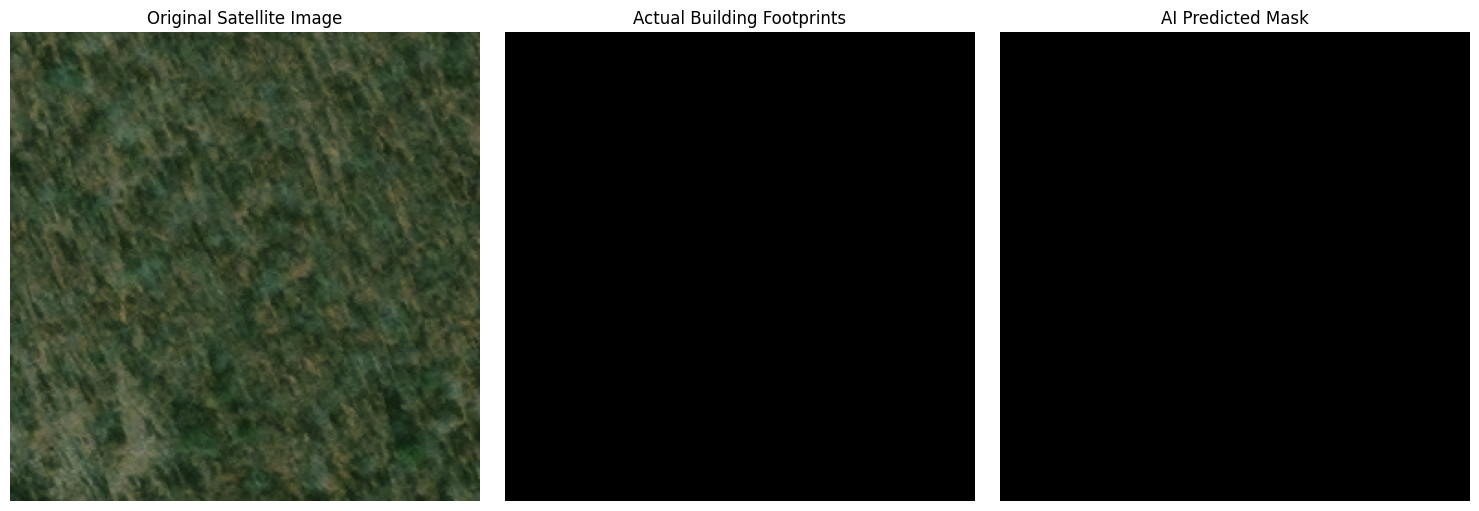

<Figure size 640x480 with 0 Axes>

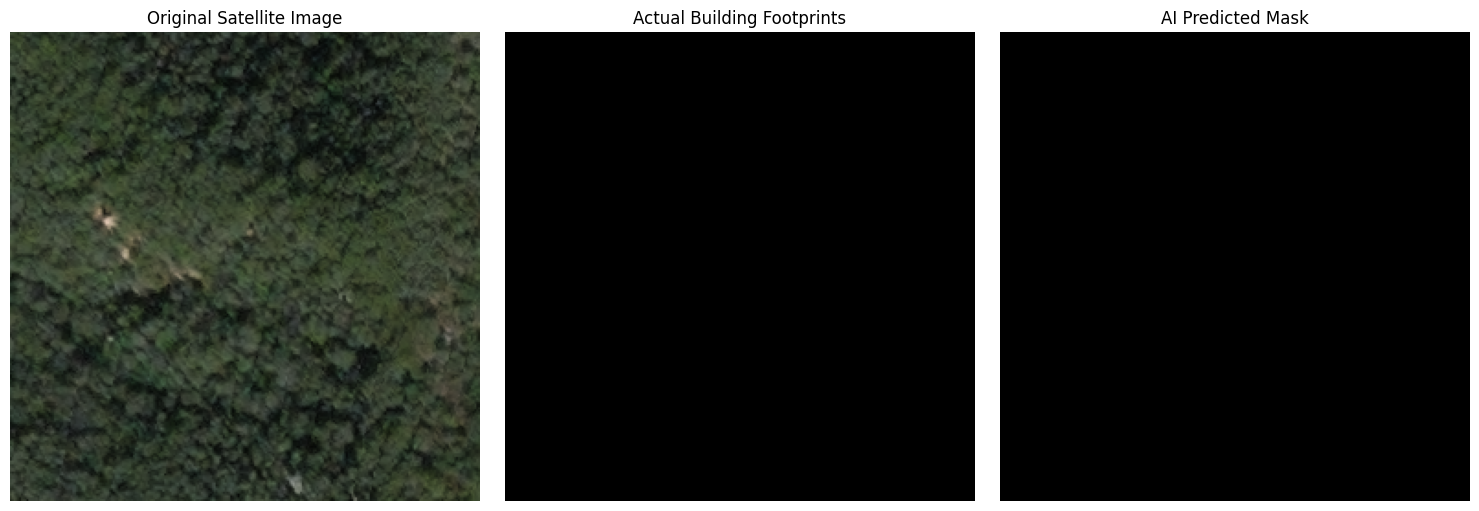

<Figure size 640x480 with 0 Axes>

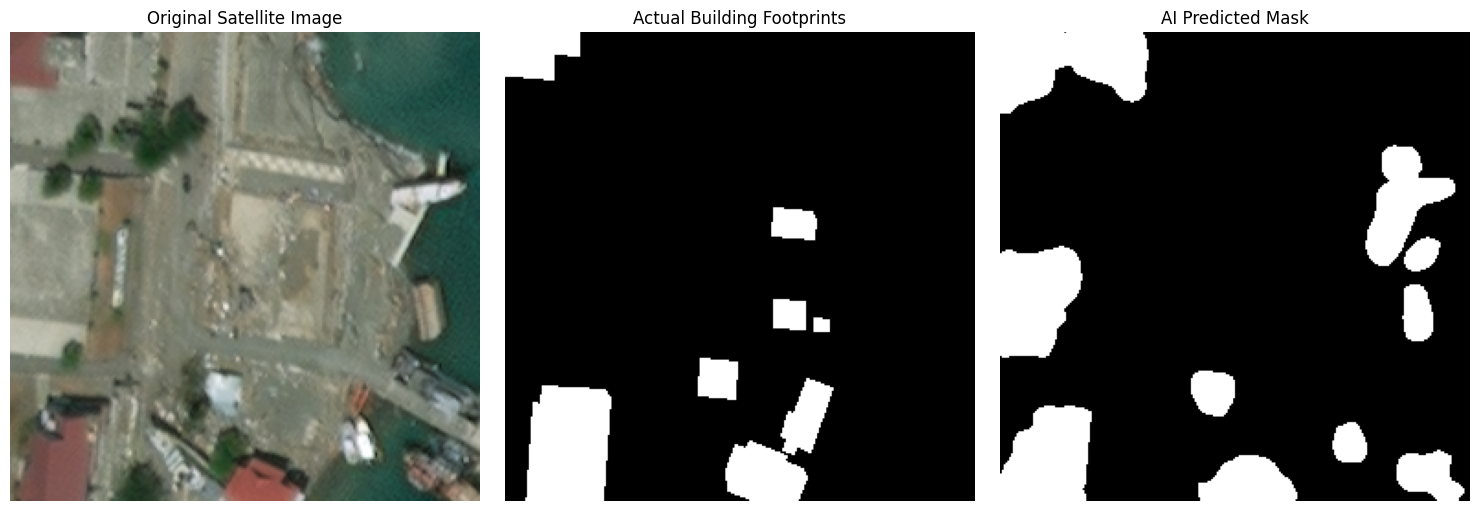

<Figure size 640x480 with 0 Axes>

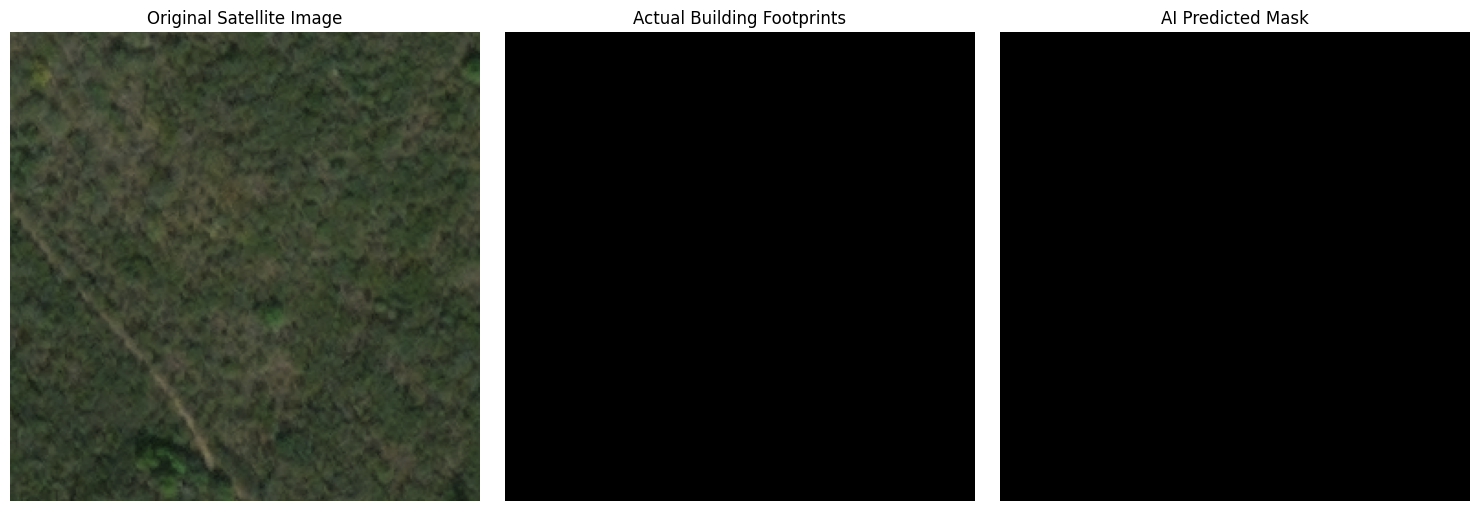

<Figure size 640x480 with 0 Axes>

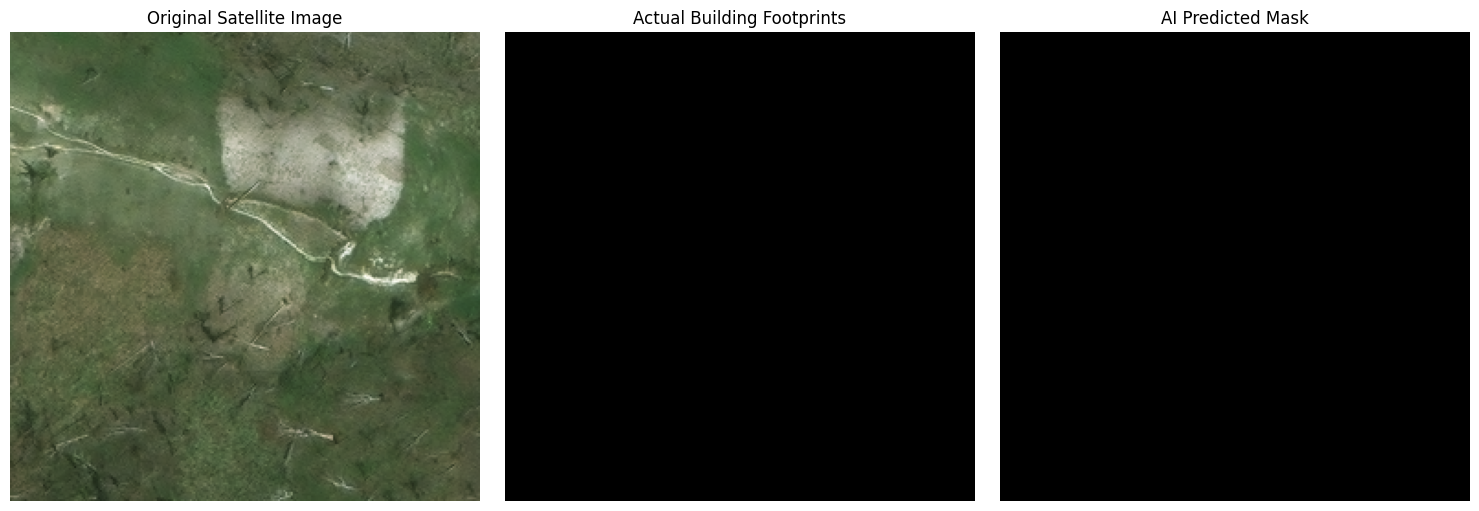

<Figure size 640x480 with 0 Axes>

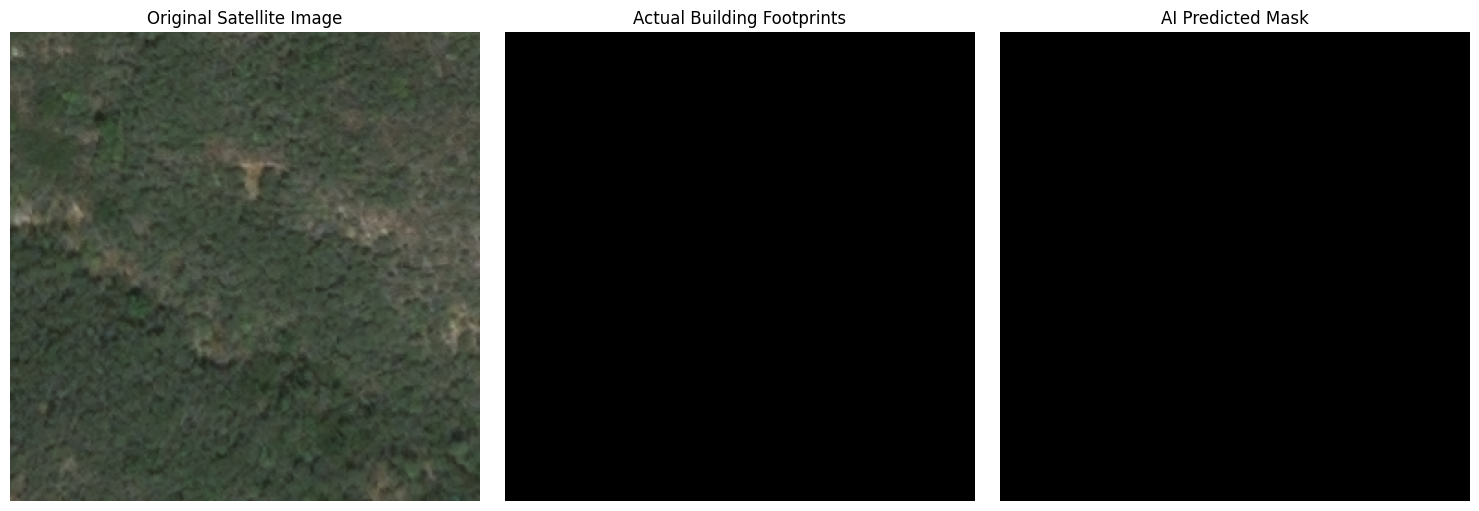

Zipping the output images...
✅ Successfully created /kaggle/working/model_predictions.zip!


<Figure size 640x480 with 0 Axes>

In [10]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import shutil

# 1. Create a dedicated folder for our output images
OUTPUT_PRED_DIR = '/kaggle/working/output_predictions'
os.makedirs(OUTPUT_PRED_DIR, exist_ok=True)

print("Loading the best model weights...")
# Load the weights that were saved during Phase 4 when validation loss was lowest
model.load_state_dict(torch.load('/kaggle/working/best_unet_model.pth'))
model.eval()

# Grab a single batch of validation data
images, true_masks = next(iter(val_loader))
images = images.to(device)

print("Generating predictions...")
with torch.no_grad():
    logits = model(images)
    probabilities = torch.sigmoid(logits)
    # Thresholding Logic (Unit I): Convert probabilities > 50% to a hard 1 (building)
    predicted_masks = (probabilities > 0.5).float() 

# Move tensors back to CPU for Matplotlib
images = images.cpu()
true_masks = true_masks.cpu()
predicted_masks = predicted_masks.cpu()

num_images = images.shape[0]
print(f"Saving {num_images} comparison plots as PNGs...")

# 2. Loop through the batch, plot, and save each one
for i in range(num_images):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Un-normalize the image so it looks normal to the human eye
    img = images[i].permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1) 
    
    # Plot Original Image
    axes[0].imshow(img)
    axes[0].set_title("Original Satellite Image")
    axes[0].axis("off")
    
    # Plot Ground Truth Mask
    axes[1].imshow(true_masks[i].squeeze(), cmap='gray')
    axes[1].set_title("Actual Building Footprints")
    axes[1].axis("off")
    
    # Plot AI Predicted Mask
    axes[2].imshow(predicted_masks[i].squeeze(), cmap='gray')
    axes[2].set_title("AI Predicted Mask")
    axes[2].axis("off")
    
    plt.tight_layout()

    plt.show()
    
    # Save the figure as a PNG
    save_path = os.path.join(OUTPUT_PRED_DIR, f"prediction_result_{i+1}.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.close(fig) # Close the figure to free up memory

# 3. Zip the entire folder into a single downloadable file
print("Zipping the output images...")
shutil.make_archive('/kaggle/working/model_predictions', 'zip', OUTPUT_PRED_DIR)

print("✅ Successfully created /kaggle/working/model_predictions.zip!")